In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install --quiet --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


In [ ]:
!cp /content/drive/MyDrive/crops.zip /content/


In [ ]:
!unzip -q /content/crops.zip -d /content/


In [ ]:
!mv /content/content/drive/MyDrive/crops /content/crops
!rm -rf /content/content


In [ ]:
import os
os.listdir('/content/crops')


['Train', 'Validation']

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.10.0+cu128
True


In [ ]:
import torchvision
print(torchvision.__version__)


0.25.0+cu128


In [ ]:
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
train_dataset = datasets.ImageFolder(
    root='/content/crops/Train',
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root='/content/crops/Validation',
    transform=val_transforms
)


In [ ]:
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Number of classes:", len(train_dataset.classes))


Train images: 15463
Val images: 3171
Number of classes: 42


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)
print(images.device)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])
cpu


In [ ]:
from torchvision import models
import torch.nn as nn


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 227MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [ ]:
from torch.amp import autocast, GradScaler

scaler = GradScaler()


In [ ]:
import time

num_epochs = 15
best_val_acc = 0.0
epoch_times = []

print(f"🚀 Training started on device: {device}")


🚀 Training started on device: cuda


In [ ]:
import os

# Mapping of incorrect → correct folder names
rename_map = {
    "bacterial_blight in Cotton": "bacterial_blight_in_cotton",
    "Bacterial Blight in cotton": "bacterial_blight_in_cotton",
    "Wheat Brown leaf Rust": "wheat_brown_leaf_rust",
    "Wheat Brown leaf rust": "wheat_brown_leaf_rust",
}

splits = ["Train", "Validation"]

base_path = "/content/crops"


In [ ]:
for split in splits:
    split_path = os.path.join(base_path, split)
    for folder in os.listdir(split_path):
        if folder in rename_map:
            old_path = os.path.join(split_path, folder)
            new_path = os.path.join(split_path, rename_map[folder])

            if not os.path.exists(new_path):
                os.rename(old_path, new_path)
                print(f"Renamed: {folder} → {rename_map[folder]}")
            else:
                # If already exists, merge contents
                for file in os.listdir(old_path):
                    os.rename(
                        os.path.join(old_path, file),
                        os.path.join(new_path, file)
                    )
                os.rmdir(old_path)
                print(f"Merged: {folder} → {rename_map[folder]}")


Renamed: bacterial_blight in Cotton → bacterial_blight_in_cotton
Renamed: Wheat Brown leaf Rust → wheat_brown_leaf_rust
Renamed: Wheat Brown leaf rust → wheat_brown_leaf_rust
Renamed: Bacterial Blight in cotton → bacterial_blight_in_cotton


In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder('/content/crops/Train')
val_dataset = datasets.ImageFolder('/content/crops/Validation')

print("Train-only classes:", set(train_dataset.classes) - set(val_dataset.classes))
print("Val-only classes:", set(val_dataset.classes) - set(train_dataset.classes))
print("Total classes:", len(train_dataset.classes))


Train-only classes: set()
Val-only classes: set()
Total classes: 42


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root='/content/crops/Train',
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root='/content/crops/Validation',
    transform=val_transforms
)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Classes:", len(train_dataset.classes))


Train images: 15463
Val images: 3171
Classes: 42


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)
model = model.to(device)


In [ ]:
num_classes = len(train_dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, num_classes)
)

model = model.to(device)


In [ ]:
# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze top blocks
for name, param in model.features.named_parameters():
    if "6" in name or "7" in name:
        param.requires_grad = True


In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)


features.6.0.block.0.0.weight
features.6.0.block.0.1.weight
features.6.0.block.0.1.bias
features.6.0.block.1.0.weight
features.6.0.block.1.1.weight
features.6.0.block.1.1.bias
features.6.0.block.2.fc1.weight
features.6.0.block.2.fc1.bias
features.6.0.block.2.fc2.weight
features.6.0.block.2.fc2.bias
features.6.0.block.3.0.weight
features.6.0.block.3.1.weight
features.6.0.block.3.1.bias
features.6.1.block.0.0.weight
features.6.1.block.0.1.weight
features.6.1.block.0.1.bias
features.6.1.block.1.0.weight
features.6.1.block.1.1.weight
features.6.1.block.1.1.bias
features.6.1.block.2.fc1.weight
features.6.1.block.2.fc1.bias
features.6.1.block.2.fc2.weight
features.6.1.block.2.fc2.bias
features.6.1.block.3.0.weight
features.6.1.block.3.1.weight
features.6.1.block.3.1.bias
features.6.2.block.0.0.weight
features.6.2.block.0.1.weight
features.6.2.block.0.1.bias
features.6.2.block.1.0.weight
features.6.2.block.1.1.weight
features.6.2.block.1.1.bias
features.6.2.block.2.fc1.weight
features.6.2.blo

In [ ]:
from torch.amp import autocast, GradScaler

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = GradScaler()


In [ ]:
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

In [ ]:
import time

num_epochs = 15
best_val_acc = 0.0
epoch_times = []

print(f"🚀 Retraining on {device}")

for epoch in range(num_epochs):
    start = time.time()
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ---- TRAIN ----
    model.train()
    correct = total = 0
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = correct / total
    train_loss /= len(train_loader)

    # ---- SAVE TRAIN METRICS ----
    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # ---- VALIDATION ----
    model.eval()
    val_correct = val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)

    # ---- SAVE VALIDATION METRICS ----
    val_acc_history.append(val_acc)
    val_loss_history.append(val_loss)

    epoch_time = time.time() - start
    epoch_times.append(epoch_time)
    avg_time = sum(epoch_times) / len(epoch_times)
    remaining = avg_time * (num_epochs - epoch - 1)

    print(f"Train Acc: {train_acc*100:.2f}% | Loss: {train_loss:.4f}")
    print(f"Val   Acc: {val_acc*100:.2f}% | Loss: {val_loss:.4f}")
    print(f"⏱️ Epoch: {epoch_time/60:.2f} min | ⏳ Remaining: {remaining/60:.2f} min")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        # Save local best weights
        torch.save(model.state_dict(), "best_model.pth")

        # Save full model to Google Drive
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": train_dataset.classes
        }, "/content/drive/MyDrive/crop_disease_model.pth")

        print("✅ Best model saved")

print(f"\n🏆 Best Validation Accuracy: {best_val_acc*100:.2f}%")

🚀 Retraining on cuda

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Train Acc: 71.49% | Loss: 1.3107
Val   Acc: 57.33% | Loss: 1.7141
⏱️ Epoch: 3.41 min | ⏳ Remaining: 47.78 min
✅ Best model saved

Epoch 2/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Acc: 90.05% | Loss: 0.4012
Val   Acc: 68.46% | Loss: 1.1764
⏱️ Epoch: 3.03 min | ⏳ Remaining: 41.85 min
✅ Best model saved

Epoch 3/15
Train Acc: 93.87% | Loss: 0.2370
Val   Acc: 79.47% | Loss: 0.8347
⏱️ Epoch: 3.04 min | ⏳ Remaining: 37.91 min
✅ Best model saved

Epoch 4/15
Train Acc: 95.89% | Loss: 0.1494
Val   Acc: 86.82% | Loss: 0.6373
⏱️ Epoch: 3.00 min | ⏳ Remaining: 34.31 min
✅ Best model saved

Epoch 5/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Acc: 97.06% | Loss: 0.1092
Val   Acc: 88.68% | Loss: 0.5832
⏱️ Epoch: 2.96 min | ⏳ Remaining: 30.87 min
✅ Best model saved

Epoch 6/15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Acc: 97.84% | Loss: 0.0769
Val   Acc: 91.55% | Loss: 0.4879
⏱️ Epoch: 2.99 min | ⏳ Remaining: 27.64 min
✅ Best model saved

Epoch 7/15
Train Acc: 98.30% | Loss: 0.0633
Val   Acc: 90.95% | Loss: 0.5189
⏱️ Epoch: 2.98 min | ⏳ Remaining: 24.47 min

Epoch 8/15
Train Acc: 98.58% | Loss: 0.0508
Val   Acc: 91.80% | Loss: 0.5205
⏱️ Epoch: 2.98 min | ⏳ Remaining: 21.34 min
✅ Best model saved

Epoch 9/15
Train Acc: 98.88% | Loss: 0.0405
Val   Acc: 91.80% | Loss: 0.5522
⏱️ Epoch: 3.03 min | ⏳ Remaining: 18.28 min

Epoch 10/15
Train Acc: 98.86% | Loss: 0.0386
Val   Acc: 92.02% | Loss: 0.5298
⏱️ Epoch: 3.06 min | ⏳ Remaining: 15.24 min
✅ Best model saved

Epoch 11/15
Train Acc: 99.21% | Loss: 0.0312
Val   Acc: 91.14% | Loss: 0.6188
⏱️ Epoch: 3.01 min | ⏳ Remaining: 12.17 min

Epoch 12/15
Train Acc: 99.25% | Loss: 0.0276
Val   Acc: 91.52% | Loss: 0.5800
⏱️ Epoch: 3.03 min | ⏳ Remaining: 9.13 min

Epoch 13/15
Train Acc: 99.17% | Loss: 0.0294
Val   Acc: 92.05% | Loss: 0.5882
⏱️ Epoch: 3.06 min |

In [ ]:
import torch
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
cm.shape


(42, 42)

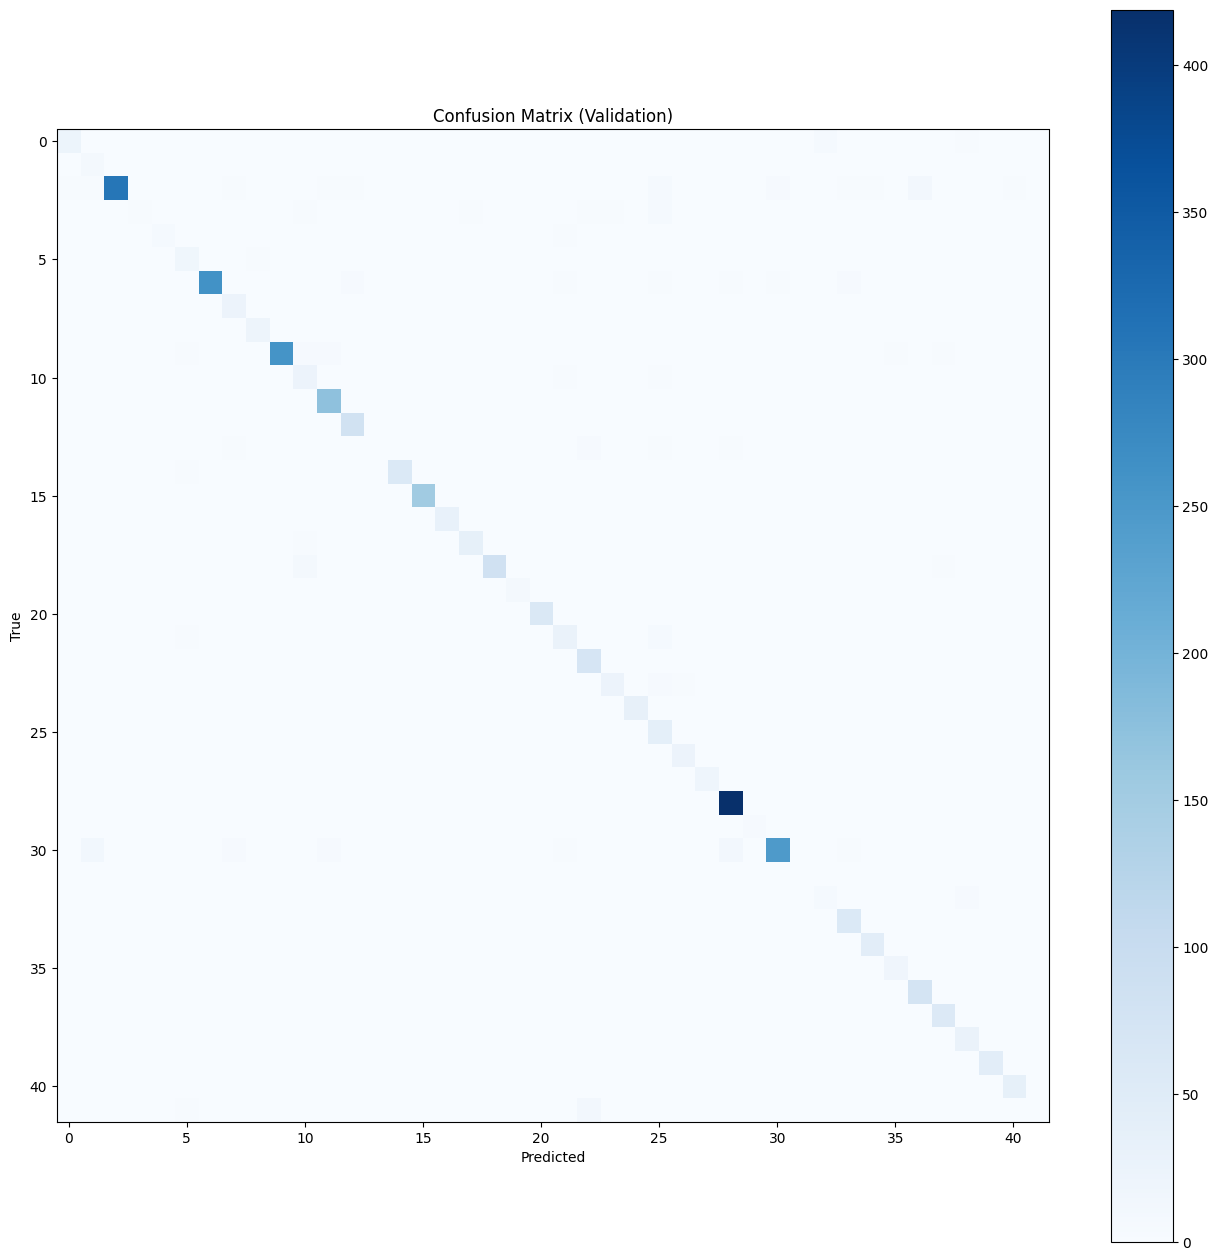

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 16))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Validation)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
class_names = train_dataset.classes

per_class_acc = {}

for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    per_class_acc[class_name] = correct / total if total > 0 else 0.0


In [ ]:
# Sort classes by accuracy
sorted_acc = sorted(per_class_acc.items(), key=lambda x: x[1])

print("🔻 Worst performing classes:")
for cls, acc in sorted_acc[:5]:
    print(f"{cls:35s} : {acc*100:.2f}%")

print("\n🔺 Best performing classes:")
for cls, acc in sorted_acc[-5:]:
    print(f"{cls:35s} : {acc*100:.2f}%")


🔻 Worst performing classes:
Leaf smut                           : 0.00%
wheat_brown_leaf_rust               : 0.00%
Becterial Blight in Rice            : 9.09%
bollrot on Cotton                   : 50.00%
bollworm on Cotton                  : 50.00%

🔺 Best performing classes:
cotton whitefly                     : 100.00%
maize ear rot                       : 100.00%
maize stem borer                    : 100.00%
red cotton bug                      : 100.00%
thirps on  cotton                   : 100.00%


In [ ]:
import torch

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes
}, "crop_disease_model.pth")


In [ ]:
from google.colab import files
files.download("crop_disease_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# -------- CONFIG --------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "crop_disease_model.pth"

# -------- LOAD CHECKPOINT --------
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
class_names = checkpoint["class_names"]

# -------- BUILD MODEL --------
model = models.efficientnet_b0(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, len(class_names))
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

# -------- IMAGE TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------- PREDICTION FUNCTION --------
def predict(image_path: str):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        confidence, idx = torch.max(probs, 1)

    return {
        "class": class_names[idx.item()],
        "confidence": float(confidence.item())
    }


In [ ]:
test_image = "/content/crops/Validation/" + train_dataset.classes[0] + "/" + \
             os.listdir(f"/content/crops/Validation/{train_dataset.classes[0]}")[0]

result = predict(test_image)
result


{'class': 'American Bollworm on Cotton', 'confidence': 0.9387043118476868}

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/crop_disease_model.pth"

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

print(checkpoint.keys())

dict_keys(['model_state_dict', 'class_names'])


In [ ]:
class_names = checkpoint["class_names"]
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First few classes:", class_names[:10])

Number of classes: 42
First few classes: ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy Maize']


In [ ]:
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, num_classes)
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(DEVICE)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root='/content/crops/Train',
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root='/content/crops/Validation',
    transform=val_transforms
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", len(train_dataset.classes))

Train images: 15463
Validation images: 3171
Classes: 42


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [ ]:
MODEL_PATH = "/content/crop_disease_model.pth"

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

class_names = checkpoint["class_names"]
num_classes = len(class_names)

In [ ]:
model = models.efficientnet_b0(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, num_classes)
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
criterion = nn.CrossEntropyLoss()

train_correct = 0
train_total = 0
train_loss = 0

with torch.no_grad():
    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        train_loss += loss.item()

        _, preds = torch.max(outputs,1)

        train_total += labels.size(0)
        train_correct += (preds==labels).sum().item()

train_acc = train_correct / train_total
train_loss /= len(train_loader)

print("Train Accuracy:", train_acc)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Accuracy: 0.7866520080191425


In [ ]:
val_correct = 0
val_total = 0
val_loss = 0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, preds = torch.max(outputs,1)

        val_total += labels.size(0)
        val_correct += (preds==labels).sum().item()

val_acc = val_correct / val_total
val_loss /= len(val_loader)

print("Validation Accuracy:", val_acc)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Validation Accuracy: 0.10879848628192999


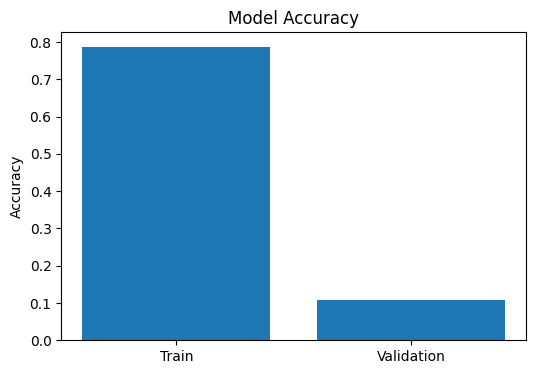

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(["Train","Validation"],[train_acc,val_acc])

plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.savefig("accuracy_graph.png",dpi=300)

plt.show()

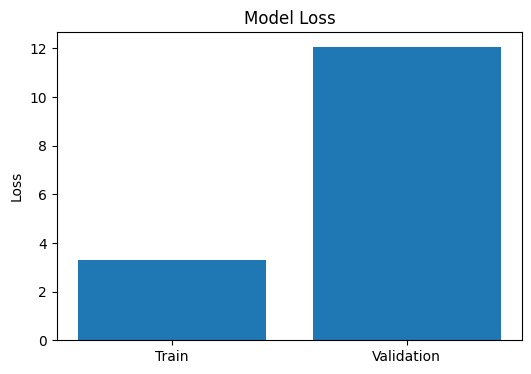

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(["Train","Validation"],[train_loss,val_loss])

plt.ylabel("Loss")
plt.title("Model Loss")

plt.savefig("loss_graph.png",dpi=300)

plt.show()

In [ ]:
# ==========================================
# Reconstruct training + validation metrics
# ==========================================

train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

criterion = torch.nn.CrossEntropyLoss()

# ---- TRAIN METRICS (single pass) ----
model.eval()
train_correct = 0
train_total = 0
train_loss = 0.0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

train_acc = train_correct / train_total
train_loss /= len(train_loader)

train_acc_history.append(train_acc)
train_loss_history.append(train_loss)


# ---- VALIDATION METRICS ----
val_correct = 0
val_total = 0
val_loss = 0.0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (preds == labels).sum().item()

val_acc = val_correct / val_total
val_loss /= len(val_loader)

val_acc_history.append(val_acc)
val_loss_history.append(val_loss)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Train Accuracy: 0.7866520080191425
Validation Accuracy: 0.10879848628192999


In [ ]:
# ==========================================
# Accuracy Graph
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_acc_history, marker='o', label="Train Accuracy")
plt.plot(val_acc_history, marker='o', label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Evaluation Step")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("accuracy_graph.png", dpi=300)

plt.show()

In [ ]:
# ==========================================
# Loss Graph
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, marker='o', label="Train Loss")
plt.plot(val_loss_history, marker='o', label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("loss_graph.png", dpi=300)

plt.show()

In [ ]:
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions collected:", len(all_preds))

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


Predictions collected: 3171


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

print("Confusion matrix shape:", cm.shape)

Confusion matrix shape: (42, 42)


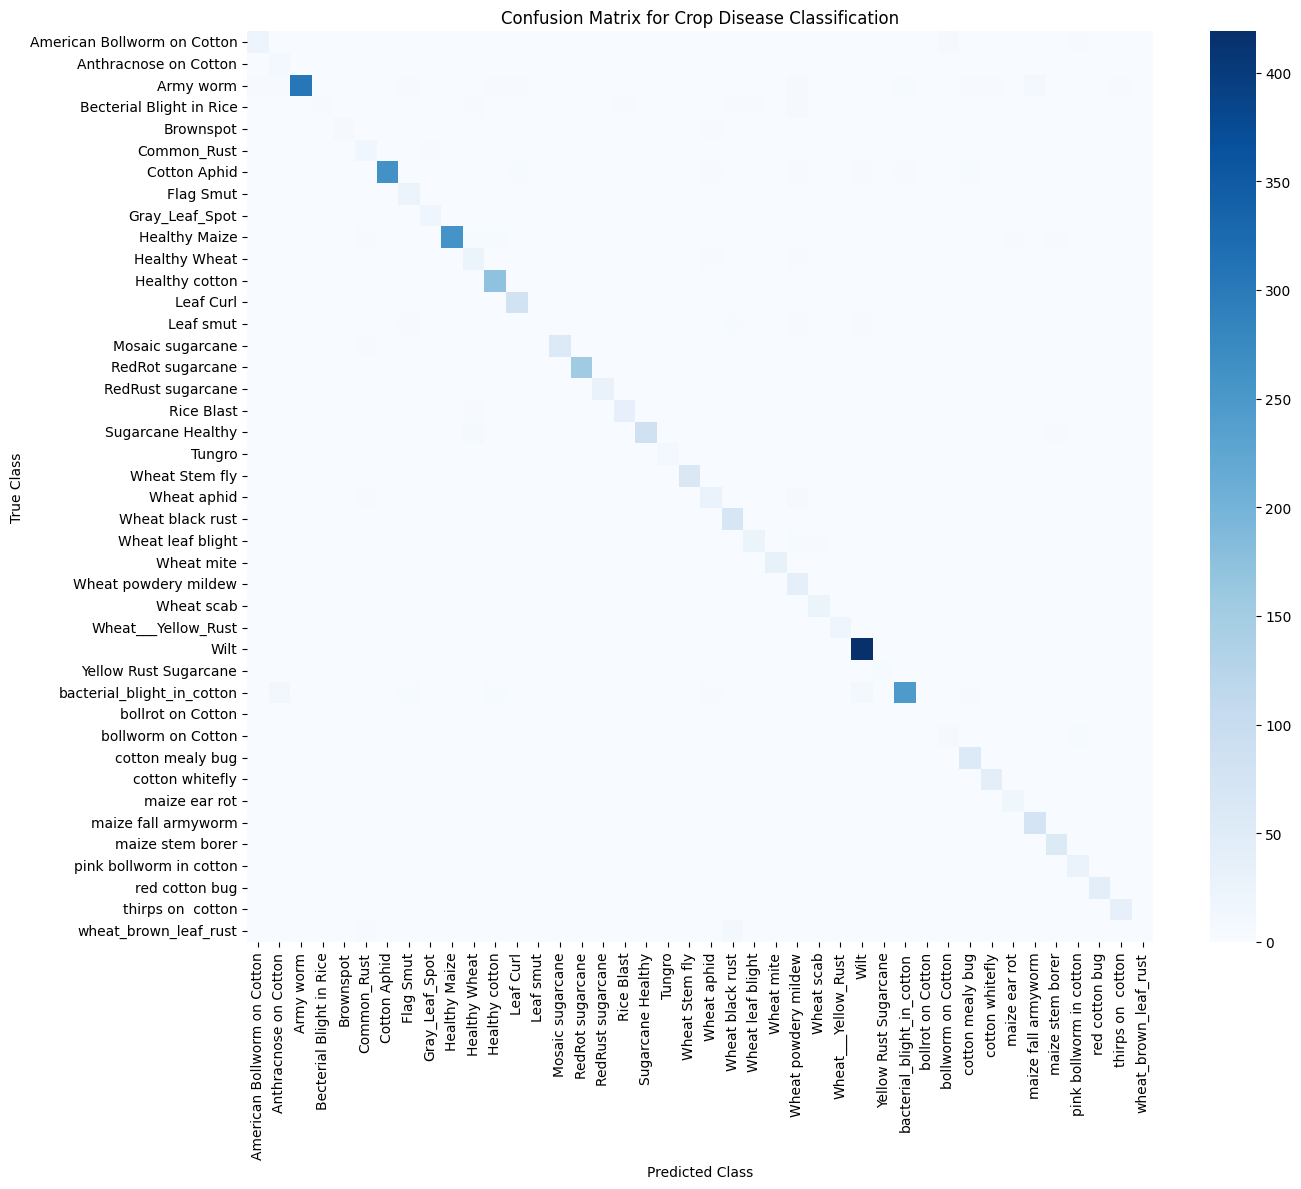

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for Crop Disease Classification")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

In [ ]:
per_class_acc = {}

for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    per_class_acc[class_name] = correct / total if total > 0 else 0

per_class_acc

{'American Bollworm on Cotton': np.float64(0.7333333333333333),
 'Anthracnose on Cotton': np.float64(0.9),
 'Army worm': np.float64(0.8689458689458689),
 'Becterial Blight in Rice': np.float64(0.09090909090909091),
 'Brownspot': np.float64(0.5555555555555556),
 'Common_Rust': np.float64(0.8888888888888888),
 'Cotton Aphid': np.float64(0.9094076655052264),
 'Flag Smut': np.float64(1.0),
 'Gray_Leaf_Spot': np.float64(1.0),
 'Healthy Maize': np.float64(0.9345454545454546),
 'Healthy Wheat': np.float64(0.696969696969697),
 'Healthy cotton': np.float64(0.9829545454545454),
 'Leaf Curl': np.float64(1.0),
 'Leaf smut': np.float64(0.0),
 'Mosaic sugarcane': np.float64(0.8787878787878788),
 'RedRot sugarcane': np.float64(1.0),
 'RedRust sugarcane': np.float64(1.0),
 'Rice Blast': np.float64(0.8181818181818182),
 'Sugarcane Healthy': np.float64(0.8723404255319149),
 'Tungro': np.float64(1.0),
 'Wheat Stem fly': np.float64(0.9838709677419355),
 'Wheat aphid': np.float64(0.7105263157894737),
 'Whe

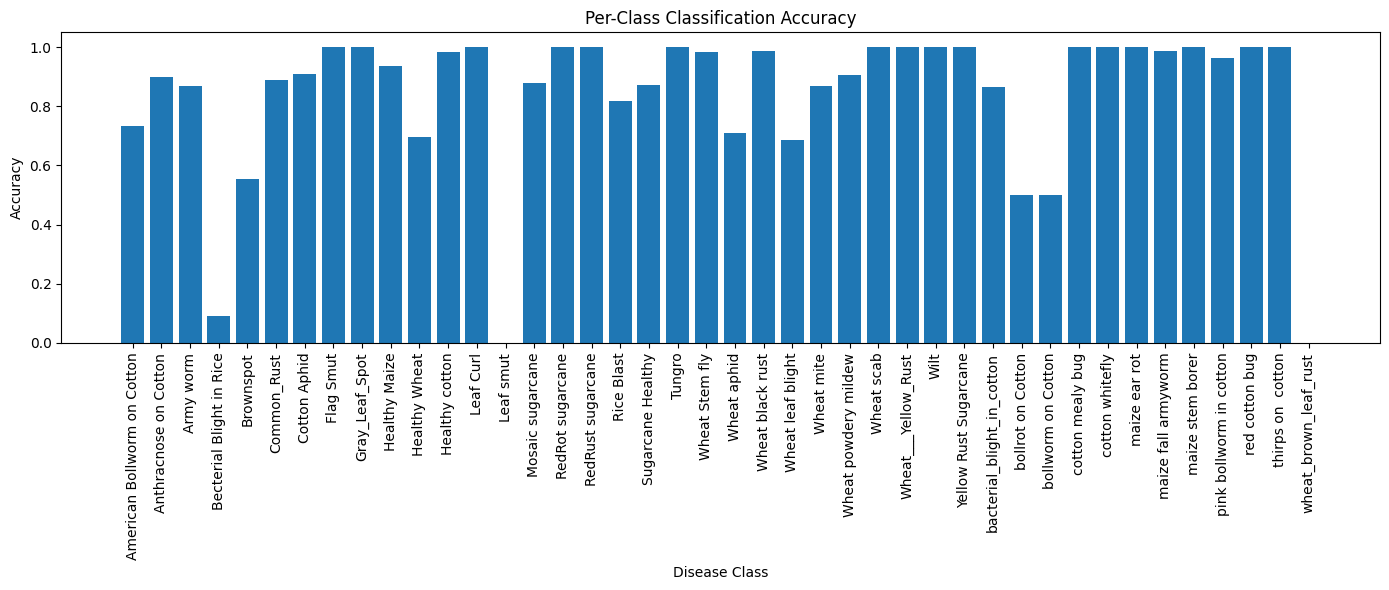

In [ ]:
import matplotlib.pyplot as plt

classes = list(per_class_acc.keys())
acc_values = list(per_class_acc.values())

plt.figure(figsize=(14,6))

plt.bar(range(len(classes)), acc_values)

plt.xticks(range(len(classes)), classes, rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Disease Class")
plt.title("Per-Class Classification Accuracy")

plt.tight_layout()

plt.savefig("per_class_accuracy.png", dpi=300)

plt.show()

In [ ]:
import os
os.listdir('/content')

['.config',
 'confusion_matrix.png',
 'crops',
 'crop_disease_model.pth',
 'per_class_accuracy.png',
 'drive',
 'crops.zip',
 'sample_data']

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print(report)

                             precision    recall  f1-score   support

American Bollworm on Cotton     0.7857    0.7333    0.7586        30
      Anthracnose on Cotton     0.3750    0.9000    0.5294        10
                  Army worm     0.9967    0.8689    0.9285       351
   Becterial Blight in Rice     0.6667    0.0909    0.1600        22
                  Brownspot     0.8333    0.5556    0.6667         9
                Common_Rust     0.4848    0.8889    0.6275        18
               Cotton Aphid     0.9886    0.9094    0.9474       287
                  Flag Smut     0.7500    1.0000    0.8571        24
             Gray_Leaf_Spot     0.8696    1.0000    0.9302        20
              Healthy Maize     1.0000    0.9345    0.9662       275
              Healthy Wheat     0.4894    0.6970    0.5750        33
             Healthy cotton     0.9402    0.9830    0.9611       176
                  Leaf Curl     0.9205    1.0000    0.9586        81
                  Leaf smut     0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
with open("classification_report.txt", "w") as f:
    f.write(report)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Overall Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Overall Accuracy: 0.912961210974456
Precision: 0.9168527455880449
Recall: 0.912961210974456
F1 Score: 0.9093946874007874


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
